<a href="https://colab.research.google.com/github/rddelarosa/DSC1105/blob/main/FA_6_DSC1105.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
library(tidyverse)
library(caret)
library(nnet)

1. **Data Exploration**:

- Load the dataset and explore the variables.

- Visualize the distribution of Age, Annual Income, and Average Spend per Visit.

- Check for missing values and handle them.

- Inspect the distribution of the target variable Customer Segment.



'data.frame':	10532 obs. of  8 variables:
 $ Customer.ID                      : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Age                              : int  56 69 46 32 60 25 38 56 36 40 ...
 $ Annual.Income..K..               : int  106 66 110 50 73 48 100 131 37 106 ...
 $ Gender                           : chr  "Female" "Female" "Male" "Male" ...
 $ Product.Category.Purchased       : chr  "Fashion" "Home" "Fashion" "Electronics" ...
 $ Average.Spend.per.Visit....      : num  163 163 105 110 142 ...
 $ Number.of.Visits.in.Last.6.Months: int  16 31 29 26 38 22 20 33 34 34 ...
 $ Customer.Segment                 : chr  "Premium Shopper" "Budget Shopper" "Budget Shopper" "Regular Shopper" ...


  Customer.ID         Age        Annual.Income..K..    Gender         
 Min.   :    1   Min.   :18.00   Min.   : 30.00     Length:10532      
 1st Qu.: 2634   1st Qu.:31.00   1st Qu.: 59.00     Class :character  
 Median : 5266   Median :43.00   Median : 89.00     Mode  :character  
 Mean   : 5266   Mean   :43.59   Mean   : 89.18                       
 3rd Qu.: 7899   3rd Qu.:56.00   3rd Qu.:118.00                       
 Max.   :10532   Max.   :69.00   Max.   :149.00                       
 Product.Category.Purchased Average.Spend.per.Visit....
 Length:10532               Min.   : 10.00             
 Class :character           1st Qu.: 56.71             
 Mode  :character           Median :104.69             
                            Mean   :104.30             
                            3rd Qu.:150.89             
                            Max.   :199.96             
 Number.of.Visits.in.Last.6.Months Customer.Segment  
 Min.   : 5.00                     Length:10532      
 1s

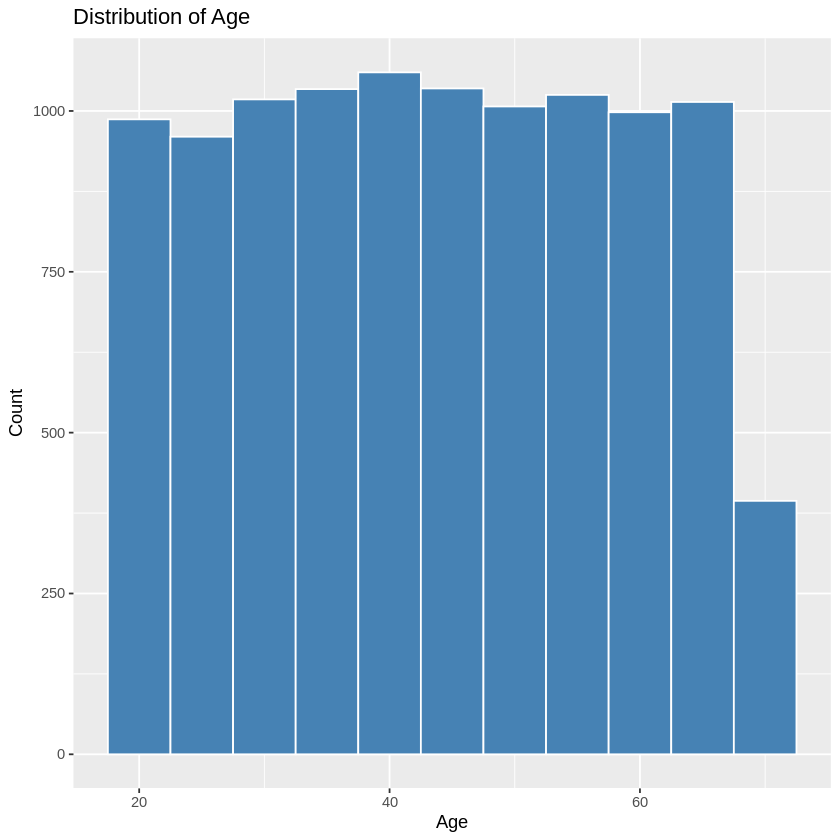

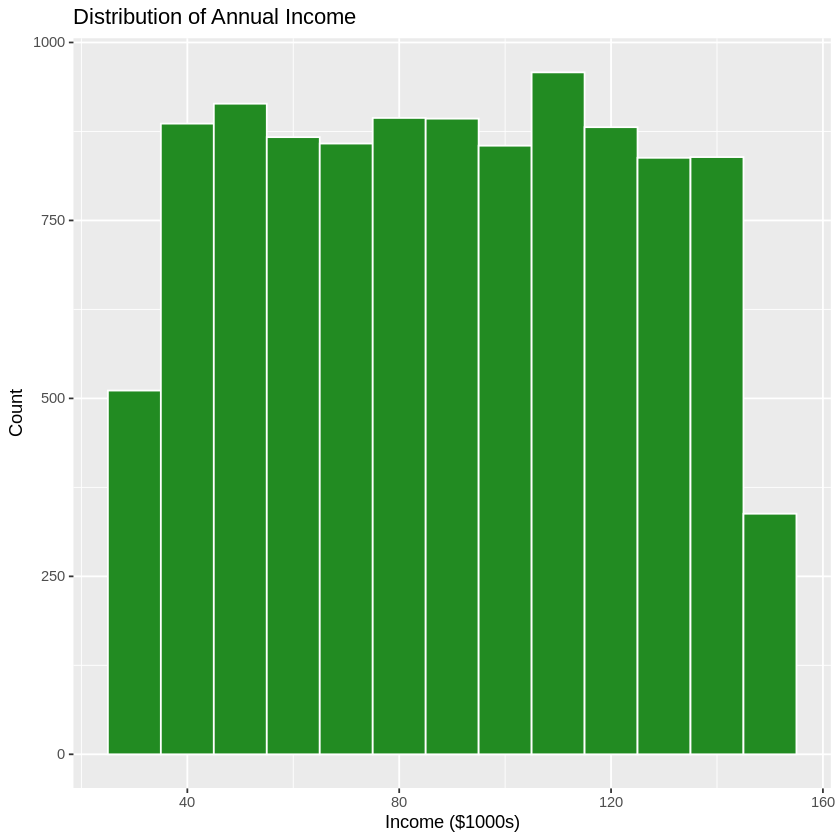

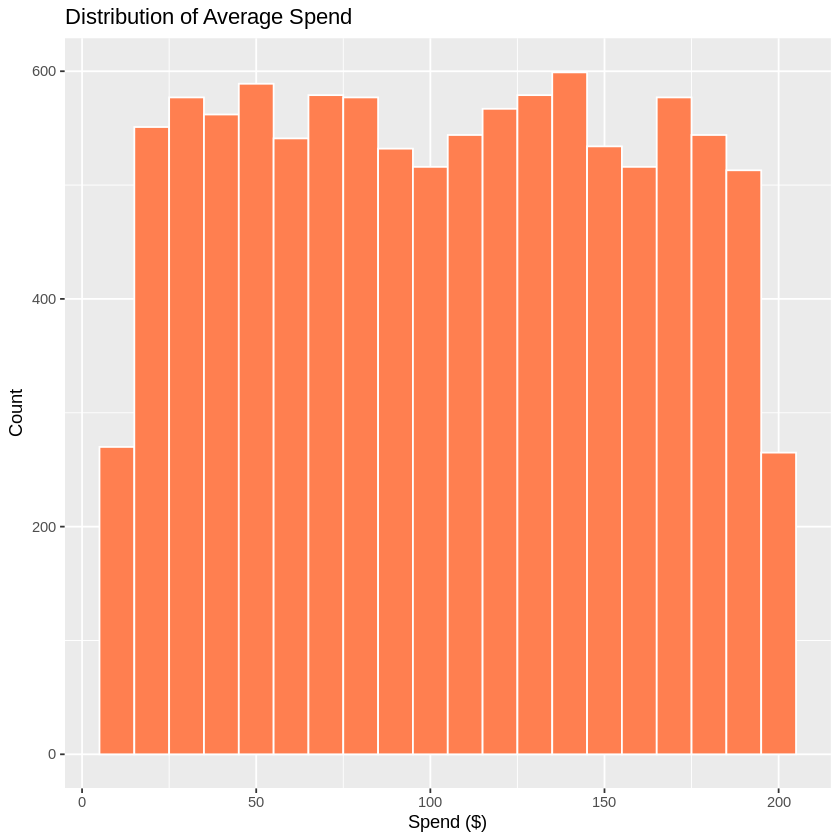

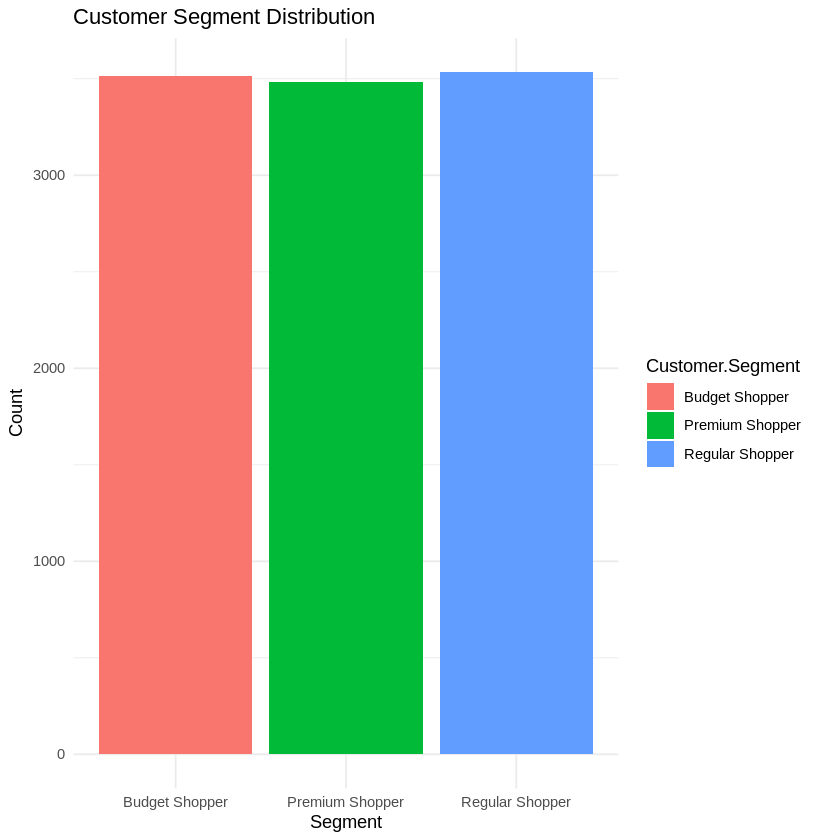

In [20]:
df <- read.csv("customer_segmentation.csv")

str(df)
summary(df)

df <- na.omit(df)

# Visualize
ggplot(df, aes(x = Age)) +
  geom_histogram(binwidth = 5, fill = "steelblue", color = "white") +
  labs(title = "Distribution of Age", x = "Age", y = "Count")

ggplot(df, aes(x = Annual.Income..K..)) +
  geom_histogram(binwidth = 10, fill = "forestgreen", color = "white") +
  labs(title = "Distribution of Annual Income", x = "Income ($1000s)", y = "Count")

ggplot(df, aes(x = Average.Spend.per.Visit....)) +
  geom_histogram(binwidth = 10, fill = "coral", color = "white") +
  labs(title = "Distribution of Average Spend", x = "Spend ($)", y = "Count")

ggplot(df, aes(x = Customer.Segment, fill = Customer.Segment)) +
  geom_bar() +
  labs(title = "Customer Segment Distribution", x = "Segment", y = "Count") +
  theme_minimal()

2. **Data Preprocessing**:

- Encode the Gender and Product Category Purchased columns using appropriate encoding methods (e.g., One-Hot Encoding for the product category, Label Encoding for gender).

- Scale continuous variables like Age, Annual Income, and Average Spend per Visit using StandardScaler or MinMaxScaler.

- Split the dataset into training and testing sets (e.g., 80% training, 20% testing).



In [21]:
df <- df %>% select(-Customer.ID)

df$Customer.Segment <- make.names(df$Customer.Segment)
df$Customer.Segment <- as.factor(df$Customer.Segment)

features <- df %>% select(-Customer.Segment)
target <- df$Customer.Segment

dummy_model <- dummyVars(" ~ .", data = features)
encoded_features <- data.frame(predict(dummy_model, newdata = features))

cols_to_scale <- c("Age", "Annual.Income..K..", "Average.Spend.per.Visit....", "Number.of.Visits.in.Last.6.Months")

preprocess_params <- preProcess(encoded_features[, cols_to_scale], method = c("center", "scale"))
encoded_features[, cols_to_scale] <- predict(preprocess_params, encoded_features[, cols_to_scale])

processed_df <- cbind(encoded_features, Customer.Segment = target)

set.seed(123)
train_index <- createDataPartition(processed_df$Customer.Segment, p = 0.8, list = FALSE)
train_data <- processed_df[train_index, ]
test_data  <- processed_df[-train_index, ]

3. **Model Building**:

- Train a multinomial logistic regression model to predict the Customer Segment based on the features.

- Use appropriate regularization and solver methods for logistic regression (e.g., solver='lbfgs' and multi_class='multinomial').

- Tune hyperparameters like regularization strength (C) using cross-validation.



In [22]:
cv_control <- trainControl(method = "cv", number = 5, classProbs = TRUE)

tune_grid <- expand.grid(decay = c(0.001, 0.01, 0.1, 1))

multinom_model <- train(
  Customer.Segment ~ .,
  data = train_data,
  method = "multinom",
  trControl = cv_control,
  tuneGrid = tune_grid,
  trace = FALSE
)

print(multinom_model$bestTune)

  decay
4     1


4. **Model Evaluation**:

- Evaluate the model using accuracy, confusion matrix, precision, recall, F1-score, and log-loss.

- Visualize the confusion matrix to see how well the model is classifying customers into the correct segments.

- Interpret the coefficients of the model to understand the relationship between the features and the customer segments.



Confusion Matrix and Statistics

                 Reference
Prediction        Budget.Shopper Premium.Shopper Regular.Shopper
  Budget.Shopper             294             278             266
  Premium.Shopper            151             148             173
  Regular.Shopper            258             270             267

Overall Statistics
                                          
               Accuracy : 0.3368          
                 95% CI : (0.3166, 0.3575)
    No Information Rate : 0.3354          
    P-Value [Acc > NIR] : 0.4531          
                                          
                  Kappa : 0.0046          
                                          
 Mcnemar's Test P-Value : 9.813e-13       

Statistics by Class:

                     Class: Budget.Shopper Class: Premium.Shopper
Sensitivity                         0.4182                0.21264
Specificity                         0.6120                0.77005
Pos Pred Value                      0.3508          

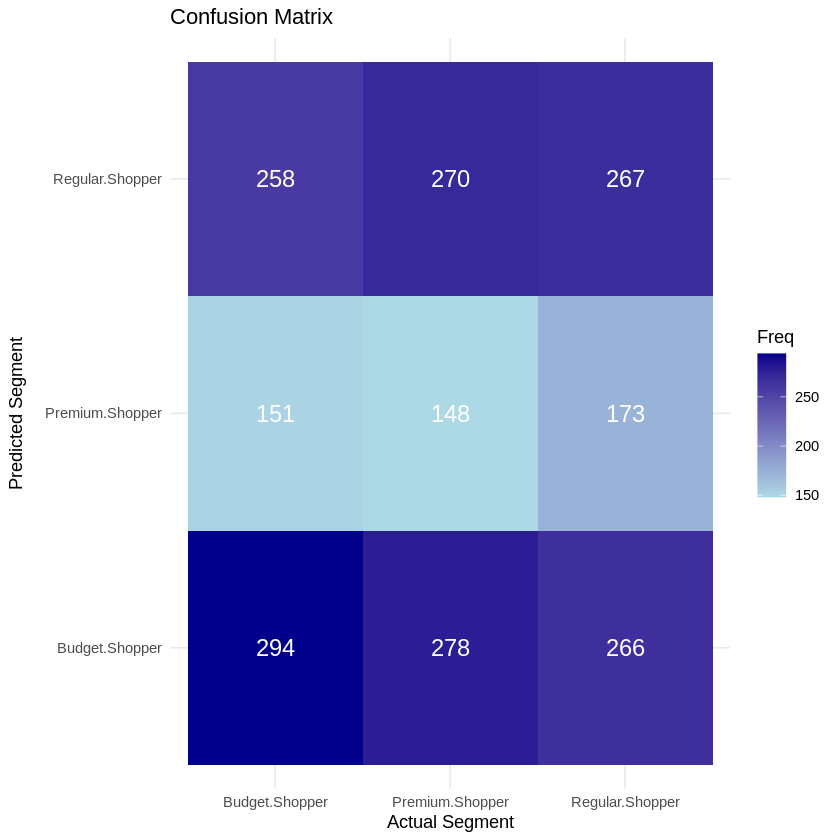

In [23]:
predictions <- predict(multinom_model, newdata = test_data)

conf_matrix <- confusionMatrix(predictions, test_data$Customer.Segment)
print(conf_matrix)

cm_df <- as.data.frame(conf_matrix$table)
ggplot(cm_df, aes(x = Reference, y = Prediction, fill = Freq)) +
  geom_tile() +
  geom_text(aes(label = Freq), color = "white", size = 5) +
  scale_fill_gradient(low = "lightblue", high = "darkblue") +
  labs(title = "Confusion Matrix", x = "Actual Segment", y = "Predicted Segment") +
  theme_minimal()

exp_coefs <- exp(coef(multinom_model$finalModel))
print("Exponentiated Coefficients:")
print(exp_coefs)

5. **Refinement**:

- Try to improve the model by adding interaction features (e.g., combining Annual Income and Age), or by tuning the hyperparameters further.

- Use cross-validation to assess the model's generalization.



In [24]:
train_data_ref <- train_data
test_data_ref <- test_data

train_data_ref$Income_Age_Interaction <- train_data_ref$Age * train_data_ref$Annual.Income..K..
test_data_ref$Income_Age_Interaction <- test_data_ref$Age * test_data_ref$Annual.Income..K..

multinom_model_ref <- train(
  Customer.Segment ~ .,
  data = train_data_ref,
  method = "multinom",
  trControl = cv_control,
  tuneGrid = tune_grid,
  trace = FALSE
)

predictions_ref <- predict(multinom_model_ref, newdata = test_data_ref)
conf_matrix_ref <- confusionMatrix(predictions_ref, test_data_ref$Customer.Segment)

print("Refined Model Accuracy:")
print(conf_matrix_ref$overall['Accuracy'])

[1] "Refined Model Accuracy:"
 Accuracy 
0.3396675 


6. **Reporting**:

- Write a report summarizing the results, including:

- How the model was built and evaluated.

- The most important features influencing customer segmentation.

- Suggestions for improving segmentation or targeting customers based on the results.



**Data Exploration & Preprocessing**
We cleaned the 10,532-row dataset by dropping missing values and removing the non-predictive `Customer.ID` column. We formatted the target labels, applied one-hot encoding to categorical variables, and scaled continuous variables (Age, Income, Spend, Visits). Finally, we split the data into 80% training and 20% testing sets.

**Model Building & Evaluation**
We trained a multinomial logistic regression model using 5-fold cross-validation (tuning the decay parameter to 1). The model performed poorly, achieving only 33.68% accuracy—barely better than random guessing among the three segments. The near-zero Kappa score (0.0046) confirmed the model struggled to find strong patterns.

**Feature Importance**
Purchasing "Fashion" was the strongest indicator of a Premium Shopper (coefficient ratio: 1.125). Age had a minor positive effect, but surprisingly, Annual Income and Average Spend showed a slight *negative* relationship with the Premium segment, which likely explains the model's low accuracy.

**Refinement**
Adding an interaction feature (Age × Annual Income) to capture the behavior of older, wealthier customers only marginally improved accuracy to 33.97%, failing to significantly boost predictive power.

**Business Suggestions**
* **Target Fashion Buyers:** Focus premium cross-selling efforts on customers who browse or purchase from the Fashion category.
* **Redefine Segments:** The current demographic variables do not cleanly separate customers into Budget, Regular, and Premium buckets. The business should rethink how these labels are assigned.
* **Track Behavioral Data:** Basic demographics aren't enough. Tracking web metrics (e.g., time on site, cart abandonment, email engagement) will yield much stronger predictive models in the future.